In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
data = pd.read_csv('imdb_movies.csv')


In [3]:
data.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [4]:
data.isnull().sum()

names          0
date_x         0
score          0
genre         85
overview       0
crew          56
orig_title     0
status         0
orig_lang      0
budget_x       0
revenue        0
country        0
dtype: int64

Genre and crew can be common in many movies

In [5]:
data.duplicated().sum()

0

In [6]:
data.iloc[10173]

names                                        20th Century Women
date_x                                              12/28/2016 
score                                                      73.0
genre                                                     Drama
overview      In 1979 Santa Barbara, California, Dorothea Fi...
crew          Annette Bening, Dorothea Fields, Lucas Jade Zu...
orig_title                                   20th Century Women
status                                                 Released
orig_lang                                               English
budget_x                                              7000000.0
revenue                                               9353729.0
country                                                      US
Name: 10173, dtype: object

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB


In [8]:
data['status'].value_counts()

status
Released           10131
Post Production       31
In Production         16
Name: count, dtype: int64

In [9]:
s = "09/01/2006"
s[-4:]
def convert_in_year(obj):
    return int(obj[-5:])

In [10]:
data['Year'] = data['date_x'].apply(convert_in_year)

In [11]:
data['Year'].value_counts()

Year
2022    954
2021    627
2019    470
2018    469
2020    449
       ... 
1930      1
1907      1
1949      1
1920      1
1903      1
Name: count, Length: 99, dtype: int64

In [12]:
data.columns

Index(['names', 'date_x', 'score', 'genre', 'overview', 'crew', 'orig_title',
       'status', 'orig_lang', 'budget_x', 'revenue', 'country', 'Year'],
      dtype='object')

EDA

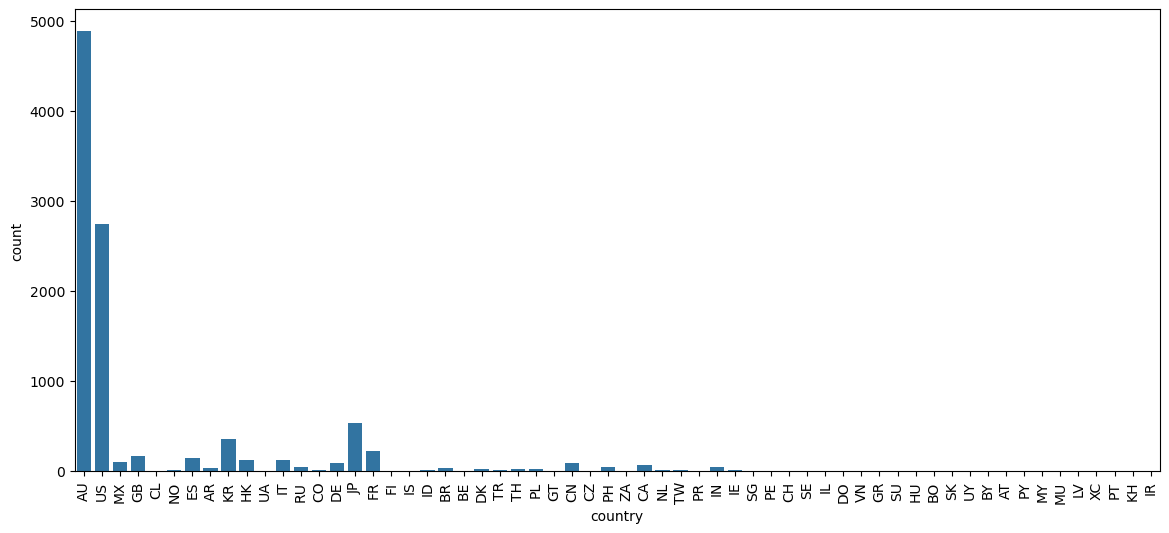

In [13]:
plt.figure(figsize=(14,6))
sns.countplot(x='country',data=data)
plt.xticks(rotation=90)
plt.show()

Most films = Austrelia , US, Mexico

In [14]:
l = list(data['genre'].unique())

In [15]:
s = set()
i =0
for g in l:
    if pd.isna(g):
        
        continue  
    j = g.split('\xa0')
    for w in j:
        if ',' in w:
            ind = w.find(',')
            w = w[:ind]
        s.add(w)
    i += 1 
print(s)
    

{'Horror', 'Music', 'Fantasy', 'Action', 'Family', 'History', 'Western', 'Adventure', 'Animation', 'Thriller', 'Drama', 'TV Movie', 'War', 'Documentary', 'Comedy', 'Science Fiction', 'Mystery', 'Crime', 'Romance'}


In [59]:
s

{'Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'History',
 'Horror',
 'Music',
 'Mystery',
 'Romance',
 'Science Fiction',
 'TV Movie',
 'Thriller',
 'War',
 'Western'}

In [64]:
gens = data['genre'].value_counts()[:5]

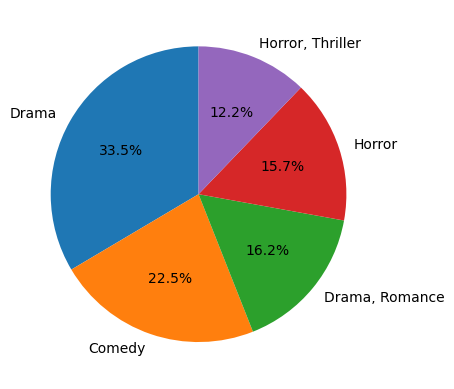

In [66]:
plt.pie(x=gens,labels=gens.index,autopct='%1.1f%%', startangle=90)
plt.show()

Lets see Language bais

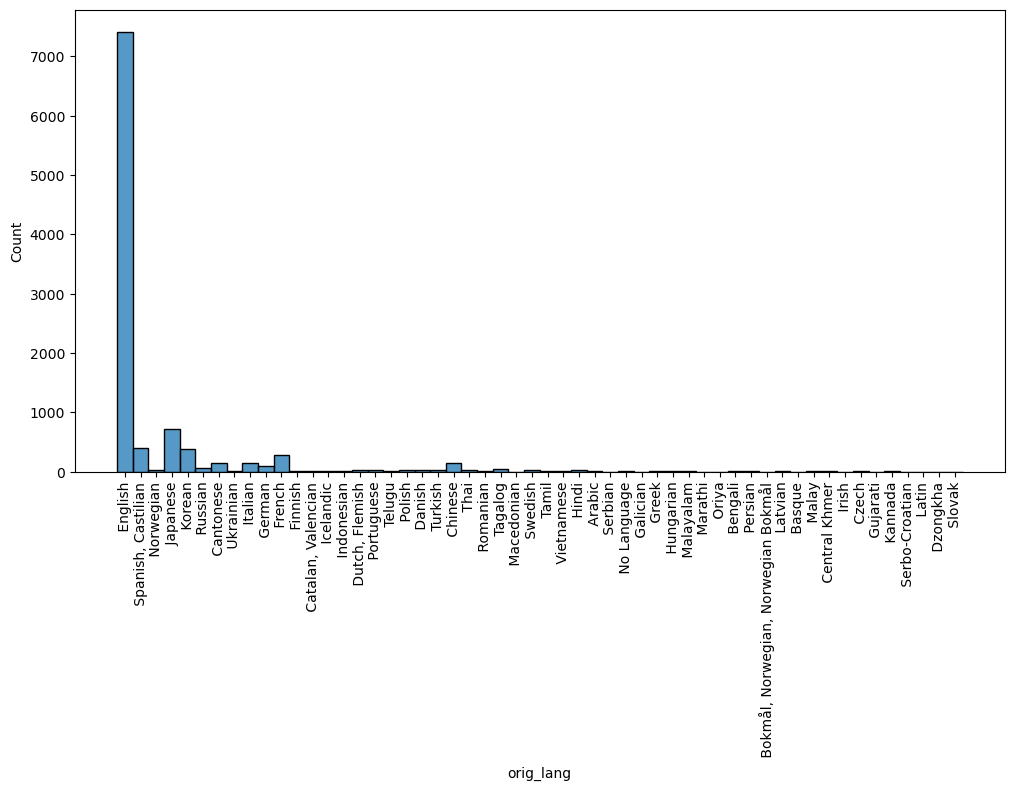

In [73]:
plt.figure(figsize=(12,6))
sns.histplot(x=data['orig_lang'],bins=10)
plt.xticks(rotation=90)
plt.show()

Almost 80 percent movies are in English in this dataset.

In [133]:
Release_years = data['Year'].value_counts()[:20][::-1]


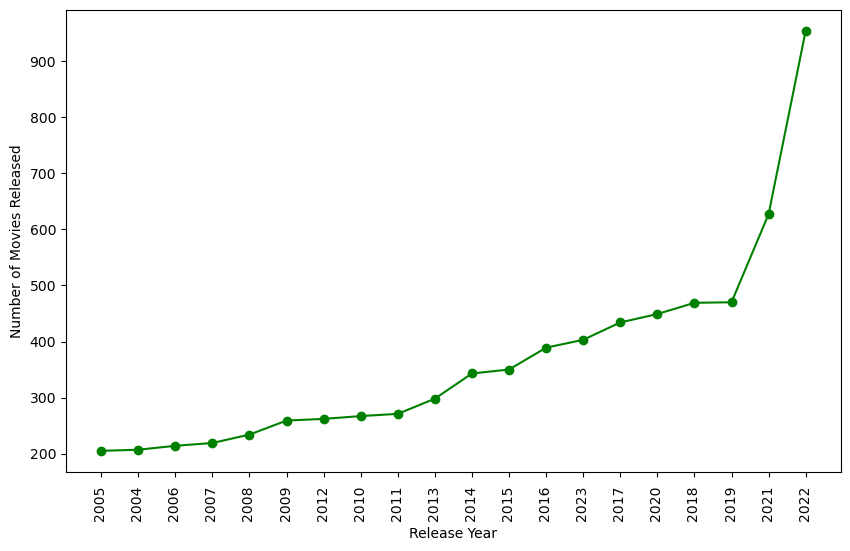

In [136]:
plt.figure(figsize=(10,6))
plt.plot(Release_years.index,Release_years,marker='o',color='green')
plt.xticks(rotation=90)
plt.xlabel("Release Year")
plt.ylabel("Number of Movies Released")
plt.show()

C:\Users\Nimisha Manawat\AppData\Local\Temp\ipykernel_12332\3994565609.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(pd.cut(data['Year'],bins=40))['names'].agg('count').plot(kind='bar',color=colors)


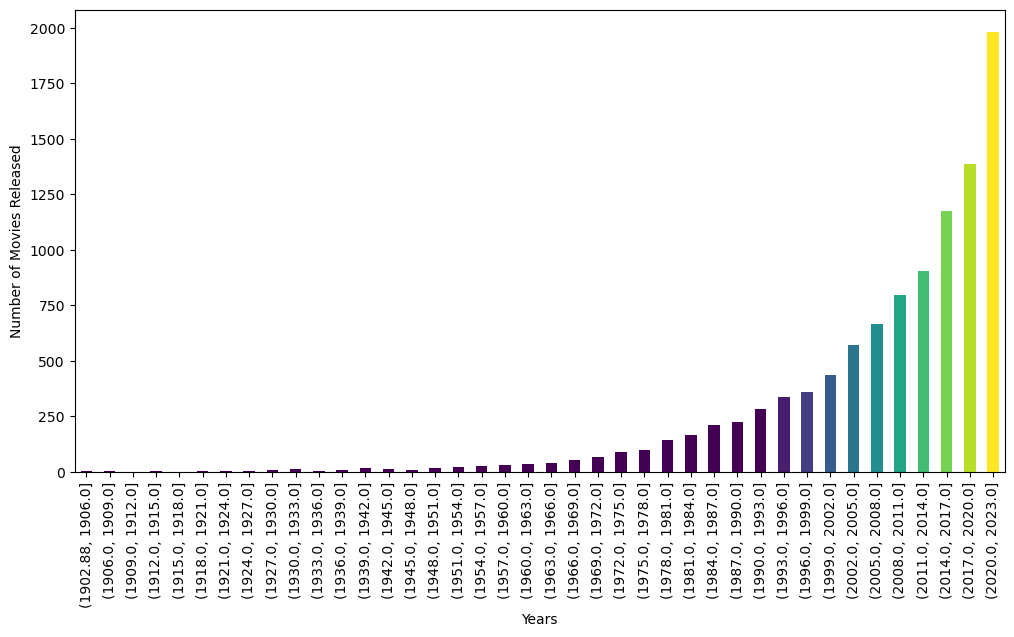

In [125]:
colors = plt.cm.viridis(np.linspace(-3, 1, 40))
plt.figure(figsize=(12,6))
data.groupby(pd.cut(data['Year'],bins=40))['names'].agg('count').plot(kind='bar',color=colors)
plt.xlabel("Years")
plt.ylabel("Number of Movies Released")
plt.show()

Recommendation System (content Based)

In [16]:
data.columns

Index(['names', 'date_x', 'score', 'genre', 'overview', 'crew', 'orig_title',
       'status', 'orig_lang', 'budget_x', 'revenue', 'country', 'Year'],
      dtype='object')

In [17]:
def convert(obj):
    k = []
    if pd.isna(obj):
        return []
        
    l = obj.split(',')
    for w in l:
        w = w.replace(" ","")
        k.append(w)
    return k 
    
        

In [18]:
def convert2(obj):
    k = []
    if pd.isna(obj):
        return []
        
    l = obj.split(',')
    for w in l:
        k.append(w)
    return k 

In [19]:
data['crew'] = data['crew'].apply(convert)

In [20]:
data['overview'] = data['overview'].apply(convert2)

In [21]:
data['orig_title'] = data['orig_title'].apply(lambda x:[x])
    

In [22]:
data['genre'] = data['genre'].apply(convert)

In [23]:
data['orig_lang'] = data['orig_lang'].apply(convert)

In [24]:
data['country'] = data['country'].apply(convert)

In [25]:
data['tags'] = data['orig_title'] +  data['genre']+data['overview']+data['crew']+data['orig_lang']+data['country'] 

In [26]:
data['tags']

0        [Creed III, Drama,  Action, After dominating t...
1        [Avatar: The Way of Water, ScienceFiction,  Ad...
2        [The Super Mario Bros. Movie, Animation,  Adve...
3        [ Momias, Animation,  Comedy,  Family,  Advent...
4        [Supercell, Action, Good-hearted teenager Will...
                               ...                        
10173    [20th Century Women, Drama, In 1979 Santa Barb...
10174    [Delta Force 2: The Colombian Connection, Acti...
10175    [The Russia House, Drama,  Thriller,  Romance,...
10176    [Darkman II: The Return of Durant, Action,  Ad...
10177    [The Swan Princess: A Royal Wedding, Animation...
Name: tags, Length: 10178, dtype: object

In [27]:
cols = ['date_x', 'score', 'genre', 'overview', 'crew', 'orig_title',
       'status', 'orig_lang', 'budget_x', 'revenue', 'country', 'Year']

In [28]:
df = data.drop(columns = cols)

In [29]:
df

,names,tags
0,Creed III,"[Creed III, Drama, Action, After dominating t..."
1,Avatar: The Way of Water,"[Avatar: The Way of Water, ScienceFiction, Ad..."
2,The Super Mario Bros. Movie,"[The Super Mario Bros. Movie, Animation, Adve..."
3,Mummies,"[ Momias, Animation, Comedy, Family, Advent..."
4,Supercell,"[Supercell, Action, Good-hearted teenager Will..."
...,...,...
10173,20th Century Women,"[20th Century Women, Drama, In 1979 Santa Barb..."
10174,Delta Force 2: The Colombian Connection,"[Delta Force 2: The Colombian Connection, Acti..."
10175,The Russia House,"[The Russia House, Drama, Thriller, Romance,..."
10176,Darkman II: The Return of Durant,"[Darkman II: The Return of Durant, Action, Ad..."


Vectorizers

In [173]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable


In [30]:
import nltk
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [31]:
def stem(text):
    y = []
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

In [32]:
df['tags'] = df['tags'].apply(lambda x:" ".join(x))

In [33]:
df['tags'] = df['tags'].apply(lambda x:x.lower())

In [34]:
df['tags'] = df['tags'].apply(stem)

In [35]:
import difflib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [36]:
tfidf = TfidfVectorizer(max_features=5000,stop_words ='english')

In [37]:
feature_vector = tfidf.fit_transform(df['tags'])

In [193]:
feature_vector

<10178x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 304279 stored elements in Compressed Sparse Row format>

In [38]:
similiraty_mat = cosine_similarity(feature_vector)

In [39]:
similiraty_mat

array([[1.        , 0.04002843, 0.00944987, ..., 0.0039907 , 0.02314462,
        0.01480334],
       [0.04002843, 1.        , 0.0305786 , ..., 0.00161812, 0.05951126,
        0.00666776],
       [0.00944987, 0.0305786 , 1.        , ..., 0.01472318, 0.00645452,
        0.07739827],
       ...,
       [0.0039907 , 0.00161812, 0.01472318, ..., 1.        , 0.00875516,
        0.00122908],
       [0.02314462, 0.05951126, 0.00645452, ..., 0.00875516, 1.        ,
        0.02859819],
       [0.01480334, 0.00666776, 0.07739827, ..., 0.00122908, 0.02859819,
        1.        ]])

In [40]:
def recommend(movie):
    all_movies = df['names'].to_list()
    close_movies = difflib.get_close_matches(movie, all_movies)
    movie_found = close_movies[0]
    idx = df[df['names']==movie_found]
    if idx.empty:
        return "movie not found"
    idx1 = idx.index[0]
    
    dist = similiraty_mat[idx1]
    movie_list = sorted(list(enumerate(dist)),reverse=True,key=lambda x:x[1])[1:6]
    l = []
    for i in movie_list:
        l.append(df.iloc[i[0]]['names'])
    return l 
    

In [42]:
recommend('Avengers')

['The Avengers',
 'Avengers: Age of Ultron',
 'Avengers: Endgame',
 'Avengers: Infinity War',
 'Captain America: Civil War']

Prediction Of Movie revenue 

In [46]:
num_cols = data.select_dtypes(['float','int']).columns

In [47]:
num_cols

Index(['score', 'budget_x', 'revenue', 'Year'], dtype='object')

In [49]:
for i in num_cols:
    if i != 'revenue':
        print(f'{i}',data[i].corr(data['revenue']))
    

score 0.09653287052495259
budget_x 0.6738295691763745
Year 0.15014297689909795


In [54]:
X = data.select_dtypes(['float','int'])

In [50]:
l = data.columns

Index(['names', 'date_x', 'score', 'genre', 'overview', 'crew', 'orig_title',
       'status', 'orig_lang', 'budget_x', 'revenue', 'country', 'Year',
       'tags'],
      dtype='object')

In [56]:
X.drop(columns ='revenue',inplace=True)

In [57]:
X

,score,budget_x,Year
0,73.0,75000000.0,2023
1,78.0,460000000.0,2022
2,76.0,100000000.0,2023
3,70.0,12300000.0,2023
4,61.0,77000000.0,2023
...,...,...,...
10173,73.0,7000000.0,2016
10174,54.0,9145817.8,1990
10175,61.0,21800000.0,1990
10176,55.0,116000000.0,1995


In [58]:
Y =data['revenue']

In [59]:
Y

0        2.716167e+08
1        2.316795e+09
2        7.244590e+08
3        3.420000e+07
4        3.409420e+08
             ...     
10173    9.353729e+06
10174    6.698361e+06
10175    2.299799e+07
10176    4.756613e+08
10177    5.394018e+08
Name: revenue, Length: 10178, dtype: float64

In [68]:
X_train,X_test = X[:8000],X[8000:]

In [60]:
X.shape

(10178, 3)

In [69]:
X_train.shape

(8000, 3)

In [70]:
Y_train,Y_test = Y[:8000],Y[8000:]

In [71]:
Y_train.shape

(8000,)

In [72]:
X_train_std = np.std(X_train,axis=0)
fixed_std = np.where(X_train_std==0,1,X_train_std)
X_scaled = (X_train - X_train.mean(axis=0))/ fixed_std

In [73]:
Y_train_std = np.std(Y_train,axis=0)
fixed_std_y = np.where(Y_train_std==0,1,Y_train_std)
Y_scaled = (Y_train - Y_train.mean(axis=0))/ fixed_std_y

In [88]:
C = np.dot(X_train.T,X_train)


In [89]:
inv = np.linalg.pinv(C)

In [90]:
comp = np.dot(X_train.T,Y_train)

In [91]:
w =np.dot(inv,comp)

In [80]:
intercept = Y_train.mean() - (X_train.mean(axis=0)@w)

In [99]:
pred = np.dot(X_train,w)

In [100]:
from sklearn.metrics import mean_squared_error,r2_score

In [101]:
mean_squared_error(Y_train,pred)

3.845543616992489e+16

In [102]:
r2_score(Y_train,pred)

0.510116305296832

In [103]:
from sklearn.linear_model import LinearRegression,Ridge

In [105]:
import xgboost as xgb

In [111]:
Xgb = xgb.XGBRegressor(n_estimators=1000,learning_rate=0.5,max_depth=3,random_state=42)
Lr = LinearRegression()
Rr = Ridge(alpha=0.5)

In [130]:
X_new = X_train.to_numpy()

In [131]:
Y_new = Y_train.to_numpy()

In [132]:
X_new.shape

(8000, 3)

In [129]:
X_new

array([[7.300e+01, 7.500e+07, 2.023e+03],
       [7.800e+01, 4.600e+08, 2.022e+03],
       [7.600e+01, 1.000e+08, 2.023e+03],
       ...,
       [6.100e+01, 2.180e+07, 1.990e+03],
       [5.500e+01, 1.160e+08, 1.995e+03],
       [7.000e+01, 9.240e+07, 2.020e+03]])

In [133]:
Xgb.fit(X_new,Y_new)
#Lr.fit(X_train,Y_train)
#Rr.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.5, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [134]:
pred_xgb = Xgb.predict(X_train)
#pred_lr = Lr.predict(X_train)
#pred_rr = Rr.predict(X_train)

In [135]:
print("Xgboost performance",mean_squared_error(Y_train,pred_xgb),r2_score(Y_train,pred_xgb))
#print("Linear regression",mean_squared_error(Y_train,pred_lr),r2_score(Y_train,pred_lr))
#print("Ridge Regression",mean_squared_error(Y_train,pred_rr),r2_score(Y_train,pred_rr))

Xgboost performance 1.3255870819199604e+16 0.831133498402598


Xgboost beats Linear Regression and Ridge Regression

In [119]:
pred_xgb_test = Xgb.predict(X_test)
pred_lr_test = Lr.predict(X_test)
pred_rr_test = Rr.predict(X_test)

In [120]:
print("Xgboost performance",mean_squared_error(Y_test,pred_xgb_test),r2_score(Y_test,pred_xgb_test))
print("Linear regression",mean_squared_error(Y_test,pred_lr_test),r2_score(Y_test,pred_lr_test))
print("Ridge Regression",mean_squared_error(Y_test,pred_rr_test),r2_score(Y_test,pred_rr_test))

Xgboost performance 2.1849197700723364e+16 0.694823567435209
Linear regression 3.116438653375925e+16 0.5647146208426688
Ridge Regression 3.1164385703799776e+16 0.5647146324350427


In [ ]:
np

In [121]:
movies = df.drop(columns='tags')

In [123]:
movies['genre'] = data['genre']

In [124]:
movies

,names,genre
0,Creed III,"[Drama, Action]"
1,Avatar: The Way of Water,"[ScienceFiction, Adventure, Action]"
2,The Super Mario Bros. Movie,"[Animation, Adventure, Family, Fantasy, Co..."
3,Mummies,"[Animation, Comedy, Family, Adventure, Fan..."
4,Supercell,[Action]
...,...,...
10173,20th Century Women,[Drama]
10174,Delta Force 2: The Colombian Connection,[Action]
10175,The Russia House,"[Drama, Thriller, Romance]"
10176,Darkman II: The Return of Durant,"[Action, Adventure, ScienceFiction, Thrille..."


In [125]:
import pickle

In [126]:
pickle.dump(movies,open('movies.pkl','wb'))

In [127]:
np.save('similarity_mats.npy',similiraty_mat)

In [136]:
pickle.dump(Xgb,open('model.pkl','wb'))

In [137]:
print(np.__version__)


1.26.4


In [138]:
print(pd.__version__)

2.2.1


In [140]:
import sklearn

In [141]:
print(sklearn.__version__)

1.5.1


In [142]:
print(nltk.__version__)

3.9.1


In [143]:
xgb.__version__

'3.0.2'

In [155]:
l = []
for i,x in enumerate(movies['genre']):
    if "Drama" in x:
        print("y")
    break 

['Drama', '\xa0Action']
y


In [156]:
movies['genre'].apply(lambda x: "Drama" in x)

0         True
1        False
2        False
3        False
4        False
         ...  
10173     True
10174    False
10175     True
10176    False
10177    False
Name: genre, Length: 10178, dtype: bool

In [161]:
filtered_movies = movies[movies['genre'].apply(lambda x: "Horror" in x)]

In [162]:
filtered_movies['names'][:10]

10    Winnie the Pooh: Blood and Honey
11                        The Exorcist
14                 The Pope's Exorcist
17                The Devil Conspiracy
25                        Consecration
34        H.P. Lovecraft's Witch House
36                                Sick
45                  Prey for the Devil
67                           Scream VI
74                         Terrifier 2
Name: names, dtype: object

In [165]:
similiraty_mat

array([[1.        , 0.04002843, 0.00944987, ..., 0.0039907 , 0.02314462,
        0.01480334],
       [0.04002843, 1.        , 0.0305786 , ..., 0.00161812, 0.05951126,
        0.00666776],
       [0.00944987, 0.0305786 , 1.        , ..., 0.01472318, 0.00645452,
        0.07739827],
       ...,
       [0.0039907 , 0.00161812, 0.01472318, ..., 1.        , 0.00875516,
        0.00122908],
       [0.02314462, 0.05951126, 0.00645452, ..., 0.00875516, 1.        ,
        0.02859819],
       [0.01480334, 0.00666776, 0.07739827, ..., 0.00122908, 0.02859819,
        1.        ]])

In [166]:

def top_k_similarities(sim_matrix, k=50):
    n = sim_matrix.shape[0]
    topk = {}

    for i in range(n):
        
        sim_scores = sim_matrix[i]
        top_indices = np.argsort(sim_scores)[::-1]  
        top_indices = top_indices[top_indices != i][:k]

        # Store only top-k similarities
        topk[i] = [(j, sim_scores[j]) for j in top_indices]

    return topk

In [167]:
new_simi_mat = top_k_similarities(similiraty_mat,50)

In [173]:
data.iloc[new_simi_mat[0][0][0]]['names']

'Creed II'

In [174]:
pickle.dump(new_simi_mat,open('top_k_similar','wb'))

In [175]:
pickle.dump(new_simi_mat,open('top_k_similar.pkl','wb'))